# Linear Regression Model

This notebook is the training and development of the linear regression model. The purpose of this model is to establish a baseline performance for the other models.

In [2]:
from pathlib import Path

import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


### Weather and water only dataset

In [3]:
data_folder = Path(r'..\..\data\model-ready\water-weather')

##### read in our model ready data

In [4]:
# train
train_X_df = pd.read_parquet(data_folder / 'scaled-X-train.parquet')
train_y_df = pd.read_parquet(data_folder / 'scaled-Y-train.parquet') # the Y data is not actually scaled inspite of the name

# test
test_X_df = pd.read_parquet(data_folder / 'scaled-X-test.parquet')
test_y = pd.read_parquet(data_folder / 'scaled-Y-test.parquet') # the Y data is not actually scaled inspite of the name

# val
val_X_df = pd.read_parquet(data_folder / 'scaled-X-val.parquet')
val_y = pd.read_parquet(data_folder / 'scaled-Y-val.parquet') # the Y data is not actually scaled inspite of the name



In [5]:
train_X_df.head(2)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp
0,0.430769,0.734694,0.0,0.659722,0.646667,0.545455,0.033333,0.0,0.430769,0.734694,0.25,0.066987,0.697431,0.959375,0.645600,0.096098
1,0.384615,0.673469,0.0,0.659722,0.666667,0.545455,0.066667,0.0,0.384615,0.673469,0.25,0.066987,0.786001,0.910151,0.658933,0.119320


In [6]:
scaler = joblib.load(data_folder / 'minmax_scaler.joblib')

##### train the model

In [7]:
model = LinearRegression()
model.fit(train_X_df, train_y_df)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 16)","[[ 0.5 , 0.35,-0.1 ,...,-0. , 2.19, 0.23]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['TMAX','TMIN','PRCP',...,'cos_day','past_10_day_ave_temp', 'past_10_day_std_temp']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[10.51]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


#### evaluate on validation and test dataset
The two sets are combined here, as the validation set it truly needed for training nueral networks, where a validation set is used to prevent overfitting.
However, to keep the comparison truly apples to apples with the other models, only the test dataset results are shown.

In [8]:
test_val_x = pd.concat([test_X_df, val_X_df], ignore_index=True)
test_val_y = pd.concat([test_y, val_y], ignore_index=True)

In [9]:
y_pred = model.predict(test_X_df)

In [10]:
test_X_df_unscaled = scaler.inverse_transform(test_X_df)

In [11]:
test_X_df = pd.DataFrame(columns=test_X_df.columns, data=test_X_df_unscaled)

In [12]:
test_X_df.head(1)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp
0,67.0,44.0,0.0,13.9,13.5,1.0,8.0,2013.0,19.444444,6.666667,0.5,0.866025,0.998717,-0.050649,14.13,0.388873


In [13]:
test_X_df['date'] = pd.to_datetime(test_X_df[['year','month','day']], errors='coerce')

In [14]:
test_X_df.head(1)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp,date
0,67.0,44.0,0.0,13.9,13.5,1.0,8.0,2013.0,19.444444,6.666667,0.5,0.866025,0.998717,-0.050649,14.13,0.388873,2013-01-08


In [15]:
test_X_df['prediction'] = y_pred
test_X_df['target'] = test_y.target.tolist()
errors = y_pred.squeeze() - np.array(test_y.target.tolist())
test_X_df['errors'] = errors

In [16]:
errors

array([ 0.08584342, -0.15144243,  0.60254871, ..., -0.42698003,
       -0.27219579,  0.02103701], shape=(4740,))

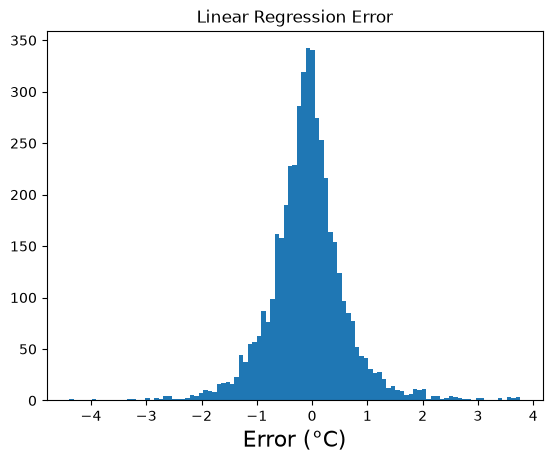

In [17]:
plt.hist(errors, bins='auto')
plt.title('Linear Regression Error')
plt.xlabel('Error (\u00b0C)', fontsize=16)
plt.show()

In [18]:
pd.DataFrame(test_X_df.errors.describe()).round().T

,count,mean,std,min,25%,50%,75%,max
errors,4740.0,-0.0,1.0,-4.0,-0.0,-0.0,0.0,4.0


In [19]:
test_X_df.head(1)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp,date,prediction,target,errors
0,67.0,44.0,0.0,13.9,13.5,1.0,8.0,2013.0,19.444444,6.666667,0.5,0.866025,0.998717,-0.050649,14.13,0.388873,2013-01-08,13.685843,13.6,0.085843


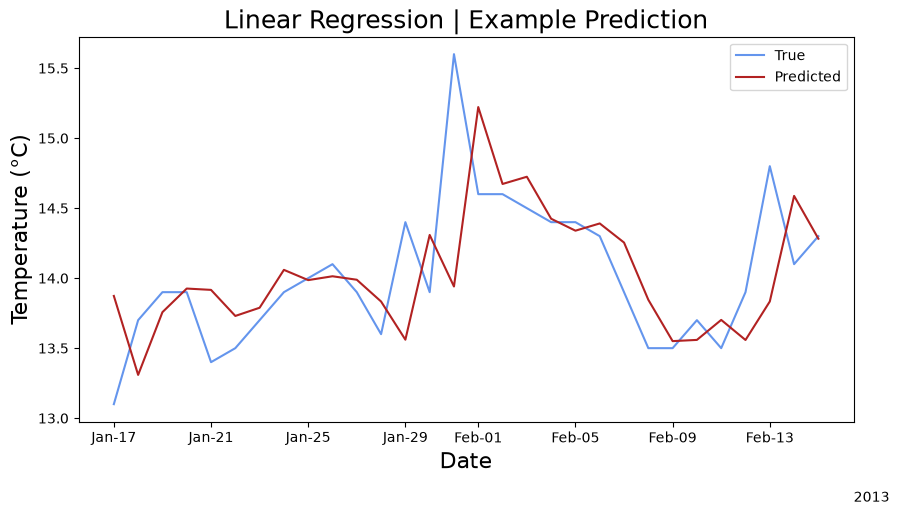

In [20]:
plot_df = test_X_df[9:39].copy()
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(plot_df.date, plot_df.target, label='True', color='cornflowerblue')
ax.plot(plot_df.date, plot_df.prediction, label='Predicted', color='firebrick')
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax.set_xlabel('Date', fontsize=16)
ax.set_title('Linear Regression | Example Prediction', fontsize=18)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
fig.text(.9, -.05, f'{int(plot_df.year.unique()[0])}')
plt.show()

In [21]:
abs(errors).max()

np.float64(4.392427741083473)

In [22]:
mae = abs(errors).mean()
mse = np.mean([errors**2])
rmse = np.sqrt(mse)
r_2 = r2_score(test_y, y_pred)
print(f'MAE = {round(mae, 2)}')
print(f'RMSE = {round(rmse, 2)}')
print(f'r2 score = {round(r_2, 2)}')

MAE = 0.49
RMSE = 0.7
r2 score = 0.94


##### Baseline RMSE and R2 Score are 0.65 and 0.94 respectively

In [23]:
output_folder = Path(r"C:\Users\speco\USD\10_capstone\src\modeling\data\test-results\no-wind")
output_file_name = 'linear-model-test-results.csv'
output_path = output_folder / output_file_name

test_X_df.to_csv(output_path, index=False)